# GEMS Prize Reference Solution

_author_: John Lipor, Associate Professor at Portland State University

# Fault Detection Using U-Net with Monte Carlo Cross-Validation

This benchmark notebook implements a deep learning approach to geological fault detection. 
The solution uses an ensemble of U-Net models trained across multiple train/test splits to 
produce predictions.

### Approach Overview:

1. Load and pre-process multi-channel geospatial features (elevation, gradients, etc.) and fault labels

1. Split feature and fault label rasters into patches

1. Train U-Net models on patches with data augmentation, applying random train/test splits for cross-validation, and using a Tversky loss function weighted to penalize false negatives more than false positives

1. Average predictions from best model across each iteration for final output

### Steps to run this notebook

1. Create a python environment and install the required dependencies using your chosen package manager.
1. Download the feature data and fault label GeoTIFFs from the [data download page](https://www.drivendata.org/competitions/306/competition-doe-gems/data/) into the `data/` directory.
1. Run the notebook!

In [1]:
import copy
import time
from pathlib import Path
from textwrap import wrap

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import segmentation_models_pytorch as smp
import torch
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms.v2 as v2
from segmentation_models_pytorch.losses import TverskyLoss
from torch.utils.data import DataLoader, Dataset
from torchvision import tv_tensors
from torchvision.transforms.functional import InterpolationMode

In [ ]:
FEATURE_DATA_PATH = Path("data/numeric_features.tif")
FAULT_LABELS_PATH = Path("data/labels.tif")

In [3]:
# set device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


# Load datasets

In [4]:
# Load feature data, print out band information
bands = []
with rasterio.open(FEATURE_DATA_PATH) as src:
    feature_meta = src.meta.copy()
    feature_nodata = src.nodata
    feature_transform = src.transform
    feature_crs = src.crs
    print("Feature data metadata:")
    print(f"  Width: {src.width}")
    print(f"  Height: {src.height}")
    print(f"  CRS: {src.crs}")
    print(f"  Resolution: {src.res[0]} x {src.res[1]}")
    print(f"  Data type: {src.dtypes[0]}")
    print(f"  nodata value: {src.nodata}")
    print("Feature data bands:")
    for i in range(1, src.count + 1):
        band_meta = src.tags(i)
        print(
            f"Band {i}: {band_meta['description']} (Category: {band_meta['data_category']})"
        )
        bands.append(band_meta)

    feature_data = src.read()

X_orig = feature_data
X_orig[X_orig < -1e38] = np.nan

# reshape to (height, width, n_features)
X_orig = np.moveaxis(X_orig, 0, -1)


# normalize all channels to [0, 1]
X_orig = (X_orig - np.nanmin(X_orig, axis=(0, 1))) / (
    np.nanmax(X_orig, axis=(0, 1)) - np.nanmin(X_orig, axis=(0, 1))
)
n_features = X_orig.shape[-1]
print(f"Feature data shape after loading: {X_orig.shape}")

Feature data metadata:
  Width: 3292
  Height: 3730
  CRS: EPSG:32611
  Resolution: 100.0 x 100.0
  Data type: float32
  nodata value: -3.4028234663852886e+38
Feature data bands:
Band 1: Magnetic anomaly - deviation from expected Earth's magnetic field (Category: magnetic_data)
Band 2: Reduced to pole magnetic data - magnetic anomaly corrected for latitude effects (Category: magnetic_data)
Band 3: Total magnetic intensity horizontal gradient - rate of change in horizontal direction (Category: magnetic_data)
Band 4: Geodetic second invariant - measure of strain rate tensor magnitude (Category: geodetic_strain)
Band 5: Isostatic gravity anomaly slope - gradient of gravity after isostatic correction (Category: gravity_data)
Band 6: Tilt angle or total curvature - magnetic field derivative for edge detection (Category: magnetic_data)
Band 7: Geodetic shear rate - rate of angular deformation from GPS/InSAR (Category: geodetic_strain)
Band 8: Geodetic dilatation rate - rate of volumetric str

In [5]:
# Load fault label data
with rasterio.open(FAULT_LABELS_PATH) as src:
    label_meta = src.meta.copy()
    label_nodata = src.nodata
    label_transform = src.transform
    label_crs = src.crs
    print("Fault label data metadata:")
    print(f"  Width: {src.width}")
    print(f"  Height: {src.height}")
    print(f"  CRS: {src.crs}")
    print(f"  Resolution: {src.res[0]} x {src.res[1]}")
    print(f"  Data type: {src.dtypes[0]}")
    print(f"  nodata value: {src.nodata}")
    print("Fault label data bands:")
    band_meta = src.tags(1)
    print(
        f"Band {i}: {band_meta['description']} (Category: {band_meta['data_category']})"
    )
    fault_labels = src.read(1).astype(np.float32)
    print(f"Shape: {fault_labels.shape}")


y_orig = fault_labels
y_orig[y_orig < 1] = 0

Fault label data metadata:
  Width: 3292
  Height: 3730
  CRS: EPSG:32611
  Resolution: 100.0 x 100.0
  Data type: int32
  nodata value: -1.0
Fault label data bands:
Band 19: Fault locations - binary mask indicating presence of faults (Category: fault_labels)
Shape: (3730, 3292)


Text(0.5, 0.98, 'Various numeric features (EPSG:32611, 100m resolution)')

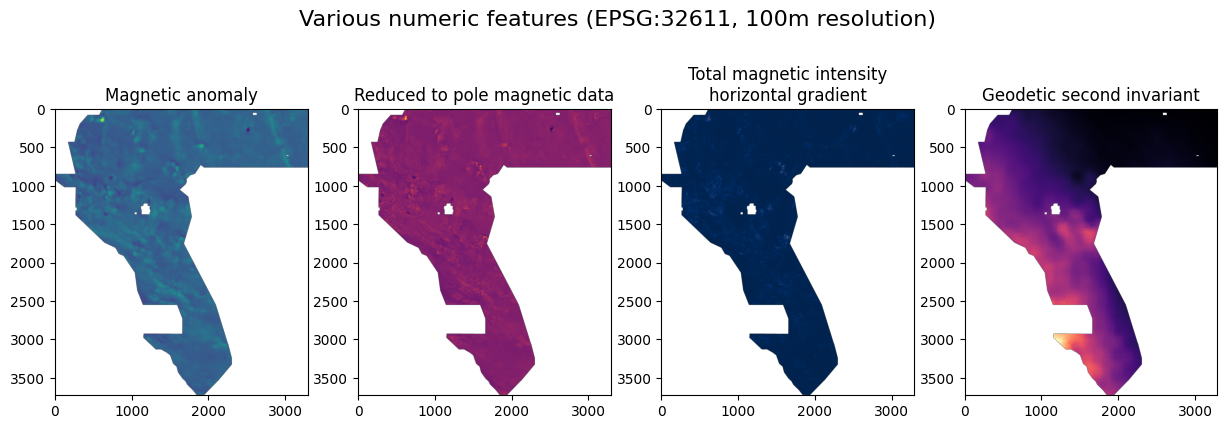

In [6]:
# show example features
cmaps = ["viridis", "inferno", "cividis", "magma"]
feature_inds = [0, 1, 2, 3]  # indices of features to display
fig, ax = plt.subplots(1, len(feature_inds), figsize=(15, 5))
for i, feature_idx in enumerate(feature_inds):
    ax[i].imshow(X_orig[:, :, feature_idx], cmap=cmaps[i])
    ax[i].set_title("\n".join(wrap(bands[i]["description"].split(" - ")[0], 30)))
plt.suptitle("Various numeric features (EPSG:32611, 100m resolution)", fontsize=16)

Text(0.5, 1.0, 'Known Faults')

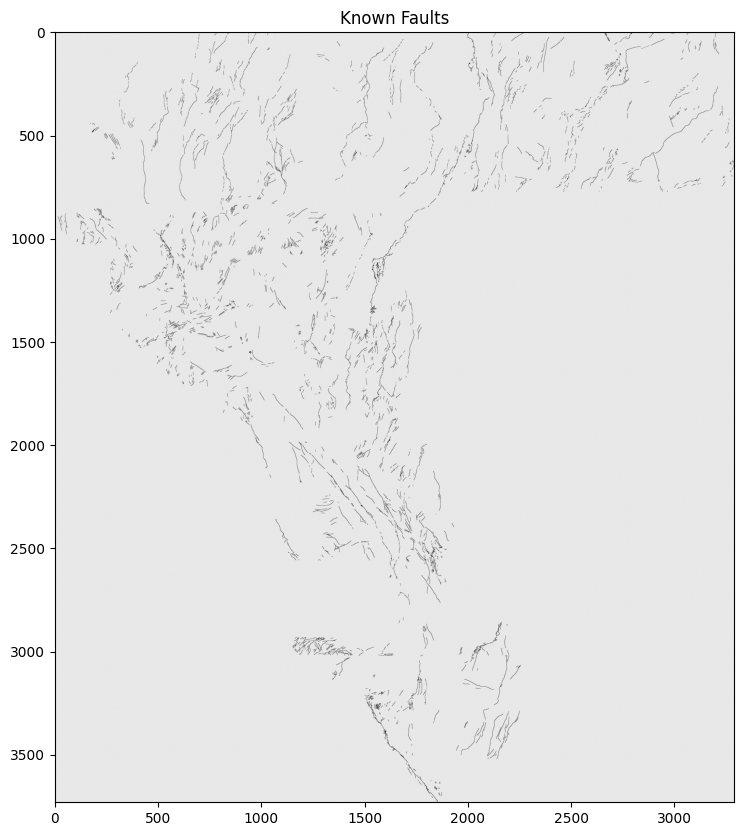

In [7]:
# show known faults
plt.figure(figsize=(10, 10))
plt.imshow(y_orig, cmap="gray_r", vmin=-0.1, vmax=1)
plt.title("Known Faults")

# Split images into patches

The below function splits the image (features and labels) into squares (patches) of size patch_size x patch_size that can be used for training. The test patches are created first, then set to zero in the global image so that there is no leakage between training and test datasets. Because there is limited training data available, the function is set up to allow for easy averaging over multiple train/test splits.

## Patch utilities

These `patchify` / `unpatchify` helpers split an image into a grid of patches and reassemble them. They are adapted from the [patchify](https://github.com/dovahcrow/patchify.py) library (MIT-licensed, Copyright 2017 Weiyüen Wu), which is unmaintained, and use scikit-image's `view_as_windows` for the split.

In [ ]:
from typing import Tuple, Union, cast

from skimage.util import view_as_windows

Imsize = Union[Tuple[int, int], Tuple[int, int, int]]


def patchify(image: np.ndarray, patch_size: Imsize, step: int = 1) -> np.ndarray:
    """
    Split a 2D or 3D image into small patches given the patch size.

    Parameters
    ----------
    image: the image to be split. It can be 2d (m, n) or 3d (k, m, n)
    patch_size: the size of a single patch
    step: the step size between patches

    Examples
    --------
    >>> image = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
    >>> patches = patchify(image, (2, 2), step=1)  # split image into 2*3 small 2*2 patches.
    >>> assert patches.shape == (2, 3, 2, 2)
    >>> reconstructed_image = unpatchify(patches, image.shape)
    >>> assert (reconstructed_image == image).all()
    """
    return view_as_windows(image, patch_size, step)


def unpatchify(patches: np.ndarray, imsize: Imsize) -> np.ndarray:
    """
    Merge patches into the original image

    Parameters
    ----------
    patches: the patches to merge. It can be patches for a 2d image (k, l, m, n)
             or 3d volume (i, j, k, l, m, n)
    imsize: the size of the original image or volume

    Examples
    --------
    >>> image = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
    >>> patches = patchify(image, (2, 2), step=1)  # split image into 2*3 small 2*2 patches.
    >>> assert patches.shape == (2, 3, 2, 2)
    >>> reconstructed_image = unpatchify(patches, image.shape)
    >>> assert (reconstructed_image == image).all()
    """

    assert len(patches.shape) / 2 == len(imsize), (
        "The patches dimension is not equal to the original image size"
    )

    if len(patches.shape) == 4:
        return _unpatchify2d(patches, cast(Tuple[int, int], imsize))
    elif len(patches.shape) == 6:
        return _unpatchify3d(patches, cast(Tuple[int, int, int], imsize))
    else:
        raise NotImplementedError(
            "Unpatchify only supports a matrix of 2D patches (k, l, m, n)"
            f"or 3D volumes (i, j, k, l, m, n), but got: {patches.shape}"
        )


def _unpatchify2d(patches: np.ndarray, imsize: Tuple[int, int]) -> np.ndarray:
    assert len(patches.shape) == 4

    i_h, i_w = imsize
    image = np.zeros(imsize, dtype=patches.dtype)

    n_h, n_w, p_h, p_w = patches.shape

    s_w = 0 if n_w <= 1 else (i_w - p_w) / (n_w - 1)
    s_h = 0 if n_h <= 1 else (i_h - p_h) / (n_h - 1)

    # The step size should be same for all patches, otherwise the patches are unable
    # to reconstruct into a image
    if int(s_w) != s_w:
        raise NonUniformStepSizeError(i_w, n_w, p_w, s_w)
    if int(s_h) != s_h:
        raise NonUniformStepSizeError(i_h, n_h, p_h, s_h)
    s_w = int(s_w)
    s_h = int(s_h)

    i, j = 0, 0

    while True:
        i_o, j_o = i * s_h, j * s_w

        image[i_o : i_o + p_h, j_o : j_o + p_w] = patches[i, j]

        if j < n_w - 1:
            j = min((j_o + p_w) // s_w, n_w - 1)
        elif i < n_h - 1 and j >= n_w - 1:
            # Go to next row
            i = min((i_o + p_h) // s_h, n_h - 1)
            j = 0
        elif i >= n_h - 1 and j >= n_w - 1:
            # Finished
            break
        else:
            raise RuntimeError("Unreachable")

    return image


def _unpatchify3d(patches: np.ndarray, imsize: Tuple[int, int, int]) -> np.ndarray:
    assert len(patches.shape) == 6

    i_h, i_w, i_c = imsize
    image = np.zeros(imsize, dtype=patches.dtype)

    n_h, n_w, n_c, p_h, p_w, p_c = patches.shape

    s_w = 0 if n_w <= 1 else (i_w - p_w) / (n_w - 1)
    s_h = 0 if n_h <= 1 else (i_h - p_h) / (n_h - 1)
    s_c = 0 if n_c <= 1 else (i_c - p_c) / (n_c - 1)

    # The step size should be same for all patches, otherwise the patches are unable
    # to reconstruct into a image
    if int(s_w) != s_w:
        raise NonUniformStepSizeError(i_w, n_w, p_w, s_w)
    if int(s_h) != s_h:
        raise NonUniformStepSizeError(i_h, n_h, p_h, s_h)
    if int(s_c) != s_c:
        raise NonUniformStepSizeError(i_c, n_c, p_c, s_c)

    s_w = int(s_w)
    s_h = int(s_h)
    s_c = int(s_c)

    i, j, k = 0, 0, 0

    while True:
        i_o, j_o, k_o = i * s_h, j * s_w, k * s_c

        image[i_o : i_o + p_h, j_o : j_o + p_w, k_o : k_o + p_c] = patches[i, j, k]

        if k < n_c - 1:
            k = min((k_o + p_c) // s_c, n_c - 1)
        elif j < n_w - 1 and k >= n_c - 1:
            j = min((j_o + p_w) // s_w, n_w - 1)
            k = 0
        elif i < n_h - 1 and j >= n_w - 1 and k >= n_c - 1:
            i = min((i_o + p_h) // s_h, n_h - 1)
            j = 0
            k = 0
        elif i >= n_h - 1 and j >= n_w - 1 and k >= n_c - 1:
            # Finished
            break
        else:
            raise RuntimeError("Unreachable")

    return image


class NonUniformStepSizeError(RuntimeError):
    """Exception raised when patches cannot be reconstructed with uniform step size."""

    def __init__(
        self, imsize: int, n_patches: int, patch_size: int, step_size: float
    ) -> None:
        super().__init__(imsize, n_patches, patch_size, step_size)
        self.n_patches = n_patches
        self.patch_size = patch_size
        self.imsize = imsize
        self.step_size = step_size

    def __repr__(self) -> str:
        return f"Unpatchify only supports reconstructing image with a uniform step size for all patches. \
However, reconstructing {self.n_patches} x {self.patch_size}px patches to an {self.imsize} image requires {self.step_size} as step size, which is not an integer."

    def __str__(self) -> str:
        return self.__repr__()

In [8]:
def make_patches(X, y, patch_size, test_proportion=0.3, seed=None, train_step=32):
    """
    Split images into patches for training and testing a neural network model.

    This function takes input features (X) and labels (y), pads them to be divisible by
    the patch size, and creates two sets of patches:
    - Test set: non-overlapping patches randomly selected
    - Training set: overlapping patches (with custom step size) from remaining areas

    Parameters:
    -----------
    X : numpy.ndarray
        Input features array of shape (height, width, n_features)
    y : numpy.ndarray
        Label array of shape (height, width)
    patch_size : int
        Size of square patches (patch_size x patch_size)
    test_proportion : float, optional (default=0.3)
        Proportion of valid patches to use for testing (0.0 to 1.0)
    seed : int, optional (default=None)
        Random seed for reproducibility. If None, uses seed=0
    train_step : int, optional (default=32)
        Step size for creating overlapping training patches. Smaller values create more overlap

    Returns:
    --------
    X_train : torch.Tensor
        Training features of shape (n_train, n_features, patch_size, patch_size)
    y_train : torch.Tensor
        Training labels of shape (n_train, patch_size, patch_size)
    X_test : torch.Tensor
        Test features of shape (n_test, n_features, patch_size, patch_size)
    y_test : torch.Tensor
        Test labels of shape (n_test, patch_size, patch_size)
    test_inds : list of tuples
        List of (row, col) indices indicating which patches were used for testing

    Notes:
    ------
    - Only patches containing labels (y > 0) and valid elevation data (channel 4) are included
    - NaN values in features are replaced with 0
    - Output tensors are in PyTorch format (channels first)
    """

    if seed is None:
        seed = 0
    rng = np.random.default_rng(seed)

    n_features = X.shape[-1]

    # pad image to be divisible by patch_size
    pad = patch_size - np.array(X.shape[:2]) % patch_size
    X = np.pad(
        X, ((0, pad[0]), (0, pad[1]), (0, 0)), mode="constant", constant_values=np.nan
    )
    y = np.pad(y, ((0, pad[0]), (0, pad[1])), mode="constant", constant_values=0)

    # create patches
    patch_shape_labels = (patch_size, patch_size)
    patch_shape_features = (patch_size, patch_size, n_features)
    step = patch_size
    X_patches = patchify(X, patch_shape_features, step)
    y_patches = patchify(y, patch_shape_labels, step)

    # find patches within the study area and containing elevation (channel 4)
    good_inds = []
    for ii in range(y_patches.shape[0]):
        for jj in range(y_patches.shape[1]):
            if np.any(y_patches[ii, jj]) and not np.all(
                np.isnan(X_patches[ii, jj, 0, :, :, 4])
            ):  # check if all values are NaN
                good_inds.append((ii, jj))

    # split out test set
    n_test = int(test_proportion * len(good_inds))
    test_inds = rng.choice(range(len(good_inds)), n_test, replace=False)
    test_inds = [good_inds[i] for i in test_inds]

    # create test set
    X_test = np.zeros((n_test, patch_size, patch_size, n_features))
    y_test = np.zeros((n_test, patch_size, patch_size))
    for i, (ii, jj) in enumerate(test_inds):
        X_test[i] = X_patches[ii, jj]
        y_test[i] = y_patches[ii, jj]
        X_patches[ii, jj] = 0
        y_patches[ii, jj] = 0

    # recombine to generate training set with overlap
    X_recovered = unpatchify(X_patches, (X.shape[0], X.shape[1], n_features))
    y_recovered = unpatchify(y_patches, (X.shape[0], X.shape[1]))

    # generate new patches
    patch_shape_features = (patch_size, patch_size, n_features)
    patch_shape_labels = (patch_size, patch_size)
    X_patches = patchify(X_recovered, patch_shape_features, train_step)
    y_patches = patchify(y_recovered, patch_shape_labels, train_step)

    # find patches within the study area and containing elevation (channel 4)
    good_inds = []
    for ii in range(y_patches.shape[0]):
        for jj in range(y_patches.shape[1]):
            if np.any(y_patches[ii, jj]) and not np.all(
                np.isnan(X_patches[ii, jj, 0, :, :, 4])
            ):  # check if all values are NaN
                good_inds.append((ii, jj))

    # create training set
    X_train = np.zeros((len(good_inds), patch_size, patch_size, n_features))
    y_train = np.zeros((len(good_inds), patch_size, patch_size))
    for i, (ii, jj) in enumerate(good_inds):
        X_train[i] = X_patches[ii, jj]
        y_train[i] = y_patches[ii, jj]

    # reshape to channels x height x width, which is the format expected by PyTorch
    X_train = torch.from_numpy(X_train).float()
    y_train = torch.from_numpy(y_train).float()
    X_test = torch.from_numpy(X_test).float()
    y_test = torch.from_numpy(y_test).float()
    X_train = X_train.permute(0, 3, 1, 2)
    X_train = torch.nan_to_num(X_train)
    X_test = X_test.permute(0, 3, 1, 2)
    X_test = torch.nan_to_num(X_test)
    y_train = torch.nan_to_num(y_train)
    y_test = torch.nan_to_num(y_test)

    return X_train, y_train, X_test, y_test, test_inds

# Train model

In [9]:
# custom dataset class
class ImageDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        # for some image transformations to work correctly, we need to cast the faults as a Mask object
        if self.transform:
            return self.transform(self.X[idx], tv_tensors.Mask(self.y[idx]))
        else:
            return self.X[idx], tv_tensors.Mask(self.y[idx])

In [10]:
# (optional) select subset of features (channels)
good_channels = list(range(n_features))  # use all channels

In [11]:
# set up parameters for training model
MC = 5  # number of Monte Carlo iterations (train/test splits)
patch_size = 128  # size of patches (inputs to model)
test_proportion = 0.5  # proportion of data to use for testing in each split
batch_size = 32
epochs = 5
init_lr = 1e-4
alpha = 0.2  # weight for false positives in Tversky loss
beta = 0.8  # weight for false negatives in Tversky loss

# image augmentations for training set
train_transform = v2.Compose(
    [
        v2.RandomResizedCrop(
            patch_size,
            scale=(0.5, 1.0),
            ratio=(0.75, 1.33),
            interpolation=InterpolationMode.BILINEAR,
        ),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomVerticalFlip(p=0.5),
        v2.RandomRotation(30),
    ]
)

# set up arrays for output image
# pad image to be divisible by patch_size
pad = patch_size - np.array(X_orig.shape[:2]) % patch_size
y_viz = np.pad(
    y_orig, ((0, pad[0]), (0, pad[1])), mode="constant", constant_values=0
)  # y_viz is the padded version of y_orig used for compiling patches

# get shape of patchified version
patch_shape_labels = (patch_size, patch_size)
step = patch_size
y_patches = patchify(y_viz, patch_shape_labels, step)
y_out = np.zeros(y_patches.shape)

# train model over multiple Monte Carlo iterations
for mc in range(MC):
    print(f"Running Monte Carlo iteration {mc + 1}/{MC}...")

    # generate new dataset and create dataloaders
    X_train, y_train, X_test, y_test, test_inds = make_patches(
        X_orig, y_orig, patch_size, test_proportion=test_proportion, seed=10 * mc
    )
    X_train = X_train[:, good_channels, :, :]
    X_test = X_test[:, good_channels, :, :]

    train_dataset = ImageDataset(X_train, y_train, transform=None)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_dataset = ImageDataset(X_test, tv_tensors.Mask(y_test), transform=None)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # load UNet model from segmentation_models_pytorch
    in_channels = X_train.shape[1]
    out_channels = 1
    model = smp.Unet(
        encoder_name="resnet18",  # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
        encoder_weights="imagenet",  # can use `imagenet` pre-trained weights for encoder initialization
        in_channels=in_channels,  # model input channels
        classes=out_channels,  # model output channels (number of classes in your dataset)
    ).to(device)

    # optimizer and loss function
    optimizer = optim.AdamW(model.parameters(), lr=init_lr)  # try adamw or others
    criterion = TverskyLoss(alpha=alpha, beta=beta, mode="binary")

    # track training and test losses
    train_batches = len(train_dataloader)
    test_batches = len(test_dataloader)
    train_losses = []
    test_losses = []

    # main training loop
    for epoch in range(epochs):
        # training loop
        model.train()
        running_loss = 0
        running_tversky = 0
        for i, (X, y) in enumerate(train_dataloader):
            # move data to device and apply transformations
            X = X.to(device)
            y = y.to(device)
            X, y = train_transform(X, tv_tensors.Mask(y))

            # compute prediction and loss
            outputs = model(X)[:, 0, :, :]
            train_loss = criterion(outputs, y[:, :, :])

            # backpropagation
            train_loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # compute scoring metrics
            yp = F.sigmoid(outputs).squeeze()
            yt = y.squeeze().int()

            running_loss += train_loss.item()
        train_losses.append(running_loss / train_batches)

        # test loop
        model.eval()
        running_loss = 0
        with torch.no_grad():
            for i, (X, y) in enumerate(test_dataloader):
                X = X.to(device)
                y = y.to(device)
                outputs = model(X)[:, 0, :, :]

                # compute scoring metrics
                yp = F.sigmoid(outputs).squeeze()
                yt = y.squeeze().int()

                running_loss += criterion(outputs, y).item()
        test_losses.append(running_loss / test_batches)

        # save model if loss is lower than previous best
        if epoch == 0:
            best_loss = test_losses[-1]
            best_model = copy.deepcopy(model)
        elif test_losses[-1] < best_loss:
            best_loss = test_losses[-1]
            best_model = copy.deepcopy(model)

        # print epoch information
        print(f"epoch {epoch}")
        print(30 * "-")
        print(f"train loss: {train_losses[-1]}")
        print(f"test loss: {test_losses[-1]}")
        print(30 * "-")
        print(f"learning rate: {optimizer.param_groups[0]['lr']}")
        time.sleep(0.0001)

    # save prediction on test_inds on full image
    best_model.eval()
    test_preds = []
    with torch.no_grad():
        for i, (X, y) in enumerate(test_dataloader):
            X = X.to(device)
            y = y.to(device)
            outputs = best_model(X)[:, 0, :, :]

            # compute scoring metrics
            yp = F.sigmoid(outputs).squeeze()
            test_preds.append(yp.cpu())

    # add test predictions to y_out
    test_preds = torch.cat(test_preds, dim=0).numpy()
    for ii in range(len(test_inds)):
        y_out[test_inds[ii][0], test_inds[ii][1], :, :] += test_preds[ii] / MC

# output map from aggregated best models
y_combined = unpatchify(y_out, (y_viz.shape[0], y_viz.shape[1]))

Running Monte Carlo iteration 1/5...
epoch 0
------------------------------
train loss: 0.9293851446488808
test loss: 0.9035092492898306
------------------------------
learning rate: 0.0001
epoch 1
------------------------------
train loss: 0.9077630161211409
test loss: 0.8922889629999796
------------------------------
learning rate: 0.0001
epoch 2
------------------------------
train loss: 0.883761923888634
test loss: 0.8722012042999268
------------------------------
learning rate: 0.0001
epoch 3
------------------------------
train loss: 0.8613379983038738
test loss: 0.8587038616339365
------------------------------
learning rate: 0.0001
epoch 4
------------------------------
train loss: 0.842181306460808
test loss: 0.8532774647076925
------------------------------
learning rate: 0.0001
Running Monte Carlo iteration 2/5...
epoch 0
------------------------------
train loss: 0.9325133587560083
test loss: 0.9235472778479258
------------------------------
learning rate: 0.0001
epoch 1
--

Text(0.5, 1.0, 'Predicted Faults')

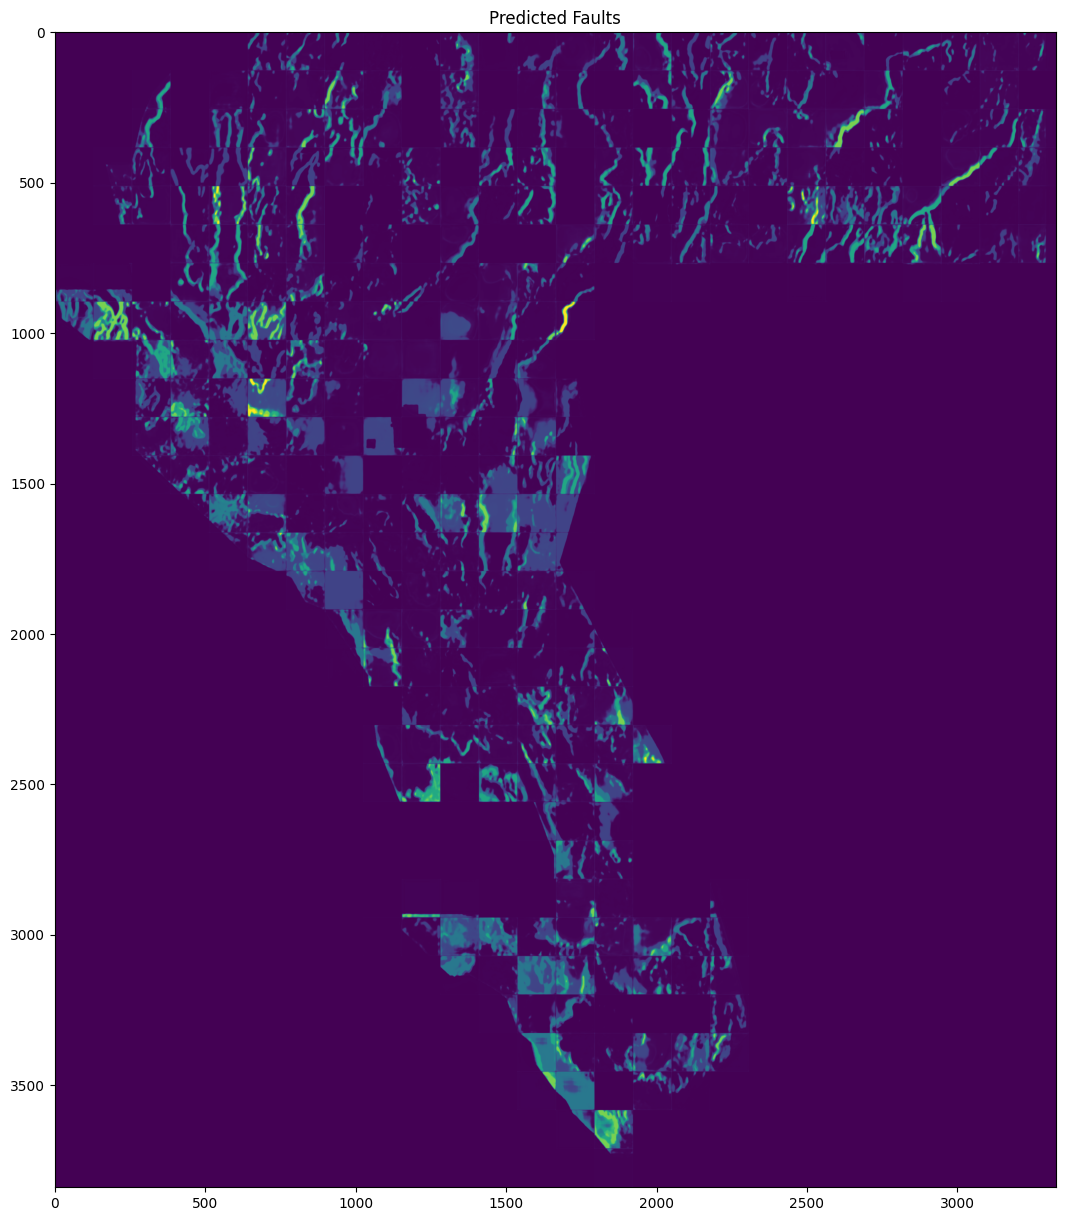

In [12]:
# display final prediction map
# NOTE: it may be advantageous to threshold this map for better scoring
plt.figure(figsize=(15, 15))
plt.imshow(y_combined)
plt.title("Predicted Faults")

# Save final prediction in required format

In [14]:
# match size to original image
y_final = y_combined[: y_orig.shape[0], : y_orig.shape[1]]

# get CRS and georeferencing from faults.tif
fname_out = "predicted_faults_example.tif"
fault_dataset = rasterio.open(FAULT_LABELS_PATH)

new_dataset = rasterio.open(
    fname_out,
    "w",
    driver="GTiff",
    height=y_final.shape[0],
    width=y_final.shape[1],
    count=1,
    dtype=y_final.dtype,
    crs=fault_dataset.crs,
    transform=fault_dataset.transform,
)
new_dataset.write(y_final, 1)
new_dataset.close()

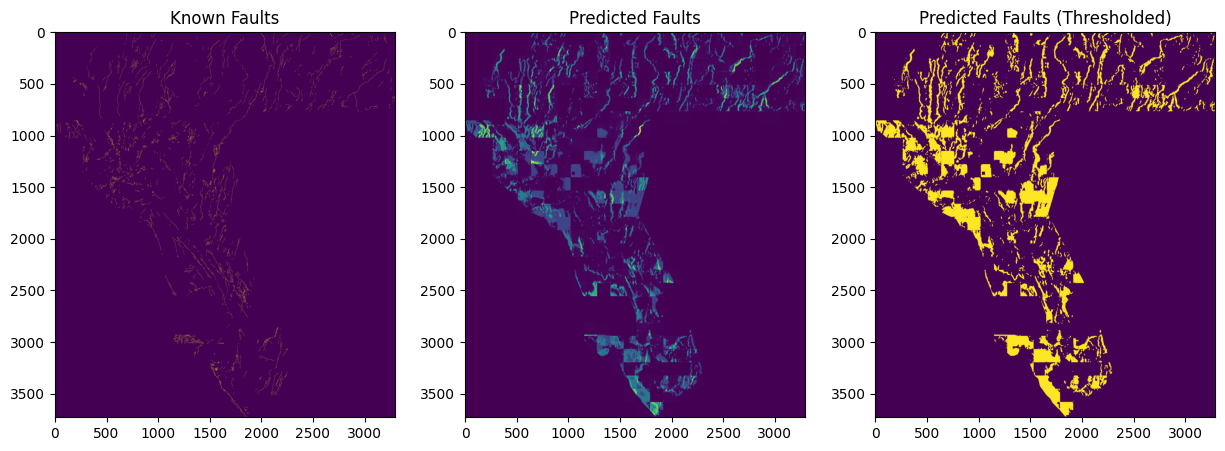

In [15]:
# visualize final predictions, including thresholded version
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(y_orig)
ax[0].set_title("Known Faults")
ax[1].imshow(y_final)
ax[1].set_title("Predicted Faults")
ax[2].imshow(y_final > 0.1)
ax[2].set_title("Predicted Faults (Thresholded)")